In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
from pathlib import Path

import numpy as np
import pandas as pd

from phd_project.scripts import metaregression_analysis as mra
from phd_project.scripts.femap695_records import femap695_record_tags
from phd_project.config import config

cfg = config.load_config()

In [ ]:
# Number of bootstrap replications. One record sample is drawn per replicate and
# reused at every structure - see 1.1. Dropped to 10 to re-save every output in the merged
# one-file-per-output layout quickly; raise it back before reading anything into a result.
K_SAMPLES = 5000

# Storey counts to bootstrap. Only the 3s group IDAs are complete; append 5 once the
# 5s runs finish - nothing else needs to change.
N_STOREYS = [3, 5]

# The IM the fragilities are expressed in (selects the collapse-IML table).
IM_TAG = "AvgSA_03"

# Reload a previously saved bootstrap instead of refitting it, when every file it needs
# is already on disk. The fits are deterministic, so this only trades ~5 min of MLE for a
# read. Set False to force a recompute (after changing K_SAMPLES, the seed, the screen,
# or the underlying analysis results).
REUSE_SAVED = True

BOOTSTRAP_PTH = cfg["proc_data"]["bootstrapping"]
SAMPLES_CSV = BOOTSTRAP_PTH / "femap695_bootstrapped_indices.csv"

# IDA arm: per-record collapse capacities (nb 053) and the group fragility summary,
# which also carries each group's member sites.
_iml_stem = Path(cfg["proc_data"]["wp1_groups_femap695_collapse_imls"])
COLLAPSE_IML_CSV = _iml_stem.with_name(f"{_iml_stem.stem}_{IM_TAG}.csv")
GROUP_FC_SUMMARY = cfg["proc_data"]["wp1_groups_femap695_fc_summary"]

# IDA collapse-bracket arms (nb 053 section 10). The IDA brackets each record's collapse
# between the highest intensity that ran and the lowest that collapsed; the arm above
# uses the lower bound, these two use the upper bound and the bracket's geometric mean.
# Same estimator, same record sample - only the capacity table differs.
BRACKET_VARIANTS = ["ub", "avg"]
BRACKET_ARM = {v: f"ida_femap695_{v}" for v in BRACKET_VARIANTS}
BRACKET_IM_LABEL = {v: f"{IM_TAG}_{v}" for v in BRACKET_VARIANTS}
BRACKET_IML_CSV = {v: _iml_stem.with_name(f"{_iml_stem.stem}_{IM_TAG}_{v}.csv")
                   for v in BRACKET_VARIANTS}
BRACKET_FC_SUMMARY = Path(GROUP_FC_SUMMARY).with_name(
    "group_femap695_bracket_collapsefragility_summary.csv")

# MSA arm: per-record collapse flags at each stripe (nb 061) and the group MSA fits.
_flag_stem = Path(cfg["proc_data"]["wp1_groups_msa_femap695_collapse_flags"])
COLLAPSE_FLAGS_CSV = _flag_stem.with_name(f"{_flag_stem.stem}_{IM_TAG}.csv")
GROUP_MSA_FC_SUMMARY = cfg["proc_data"]["wp1_groups_msa_femap695_fc_summary"]

# Site-specific MSA arm: one fragility JSON per structure (nb 060). There is no summary
# CSV for this arm, so those files are also the only source of its published fits.
SITE_FC_ROOT = cfg["proc_data"]["wp1_sites_fragility_curves"]
SITES = list(range(60))
SITE_MSA_N_RECORDS = 30    # GCIM selects 30 records at every stripe (nb 017/050)

# Per-record collapse outcomes behind the site MSA fragilities (nb 060 section 6), and the
# record resamples section 1.4 draws from them. Unlike the FEMA P695 sample there is one
# resample per (site, stripe): the records are re-selected at every site and IML.
_site_flag_stem = Path(cfg["proc_data"]["wp1_sites_msa_collapse_flags"])
SITE_MSA_FLAGS_CSV = _site_flag_stem.with_name(f"{_site_flag_stem.stem}_{IM_TAG}.csv")
SITE_MSA_SAMPLES_CSV = BOOTSTRAP_PTH / f"site_msa_bootstrapped_indices_{IM_TAG}.csv"

## 1.0 Bootstrap FEMA P695 Dataset

### 1.1 Bootstrap indices

Because FEMAP695 is a fixed record set the bootstrapping only needs to be conducted once and then the same sampled records are used across all of the analyses. That way it mimics the same record set being used at all sites. (The whole idea of a fixed record set).
The sampling is based on the index of the file in the folder (i.e. 0-21). Using this index the collapse/non-collapse can be determined from the msa_log file and teh capacities can be extracted from teh ida_log file. 

In [38]:
record_tags = femap695_record_tags(cfg["raw_data"]["femap695_records"])
print(f"{len(record_tags)} records: {record_tags[0]} (tag 0) ... {record_tags[-1]} "
      f"(tag {len(record_tags) - 1})")

samples = mra.draw_record_samples(record_tags, K_SAMPLES, seed=1)
np.savetxt(SAMPLES_CSV, samples, delimiter=",", fmt="%s")

samples

22 records: fema_p695_120111 (tag 0) ... fema_p695_121711 (tag 21)


array([['fema_p695_120911', 'fema_p695_120921', 'fema_p695_121221', ...,
        'fema_p695_120111', 'fema_p695_121421', 'fema_p695_121221'],
       ['fema_p695_121411', 'fema_p695_120921', 'fema_p695_121321', ...,
        'fema_p695_121221', 'fema_p695_120121', 'fema_p695_120711'],
       ['fema_p695_120911', 'fema_p695_120911', 'fema_p695_120411', ...,
        'fema_p695_120411', 'fema_p695_120821', 'fema_p695_121021'],
       ...,
       ['fema_p695_120811', 'fema_p695_121011', 'fema_p695_120111', ...,
        'fema_p695_121021', 'fema_p695_121111', 'fema_p695_121021'],
       ['fema_p695_120711', 'fema_p695_121221', 'fema_p695_121111', ...,
        'fema_p695_121211', 'fema_p695_121221', 'fema_p695_120711'],
       ['fema_p695_121321', 'fema_p695_120821', 'fema_p695_120521', ...,
        'fema_p695_120721', 'fema_p695_121321', 'fema_p695_121021']],
      shape=(5000, 22), dtype='<U16')

In [39]:
# Reload the drawn sample, so 1.2 can be re-run without redrawing it. The checks guard
# against the sample on disk having been drawn from a different record set.
samples = np.loadtxt(SAMPLES_CSV, delimiter=",", dtype=str)
assert samples.shape == (K_SAMPLES, len(record_tags))
assert set(np.unique(samples)) <= set(record_tags)
samples.shape

(5000, 22)

### 1.2 IDA-FEMAP695 fragility parameters

Each replicate is a resample (with replacement) of the 22 FEMA P695 records. The IDA already gives a **collapse capacity per record** for every design group (nb 053, `group_femap695_collapse_imls_{IM}.csv`, in g), so a replicate is formed by looking those capacities up for the sampled record tags and refitting the lognormal by moments - the same fit `fragility_from_ida` performs. This is a non-parametric bootstrap of the real capacities, not a parametric draw from the fitted curve.

The IDA is run **per design group**, not per site, because the record set is fixed and the analysis therefore depends only on the structure. Results are written out both ways: `_by_group` (25 columns for 3s, no duplication) and `_by_site` (60 columns, sites sharing a design carrying identical columns) so the IDA arm lines up column-by-column with the per-site MSA arm.

In [40]:
record_tags = femap695_record_tags(cfg["raw_data"]["femap695_records"])

collapse_imls = mra.load_group_collapse_imls(COLLAPSE_IML_CSV, N_STOREYS, record_tags)
group_sites = mra.load_group_site_map(GROUP_FC_SUMMARY, N_STOREYS)

for n in N_STOREYS:
    sites = sorted(s for ss in group_sites[n].values() for s in ss)
    print(f"[{n}s] {collapse_imls[n].shape[0]} groups x {collapse_imls[n].shape[1]} records"
          f"  ->  {len(sites)} sites, contiguous from 0: {sites == list(range(len(sites)))}")

[3s] 25 groups x 22 records  ->  60 sites, contiguous from 0: True
[5s] 26 groups x 22 records  ->  60 sites, contiguous from 0: True


#### Fit each replicate

The moment fit is cheap, so this runs in seconds either way - but it goes through the same reuse switch as the other two arms so all three behave alike. Only the `by_group` frames are read back; the `by_site` versions are re-derived from them and the stats recomputed below, so a stale or half-written file cannot leave the two views disagreeing.

In [41]:
theta_by_group, beta_by_group = {}, {}
theta_by_site, beta_by_site = {}, {}

for n in N_STOREYS:
    saved = REUSE_SAVED and mra.load_saved_bootstrap(
        BOOTSTRAP_PTH, "ida_femap695", ("theta", "beta"), n, IM_TAG, "by_group",
        k_samples=K_SAMPLES)
    if saved:
        theta_by_group[n], beta_by_group[n] = saved["theta"], saved["beta"]
        source = "loaded"
    else:
        theta_by_group[n], beta_by_group[n] = mra.bootstrap_ida_group_fragilities(
            collapse_imls[n], samples, record_tags)
        source = "computed"

    theta_by_site[n] = mra.expand_groups_to_sites(theta_by_group[n], group_sites[n])
    beta_by_site[n] = mra.expand_groups_to_sites(beta_by_group[n], group_sites[n])
    print(f"[{n}s] theta/beta ({source}): {theta_by_group[n].shape} by group, "
          f"{theta_by_site[n].shape} by site")

theta_by_site[N_STOREYS[0]].head()

[3s] theta/beta (computed): (5000, 25) by group, (5000, 60) by site
[5s] theta/beta (computed): (5000, 26) by group, (5000, 60) by site


site,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
k,,,,,,,,,,,,,,,,,,,,,
0,0.391423,0.387744,0.387744,0.372802,0.391423,0.387744,0.387744,0.472452,0.391423,0.357241,...,0.454609,0.779126,0.628028,0.802919,0.601475,0.580687,0.563242,0.601475,0.439915,0.809067
1,0.398267,0.387259,0.387259,0.382181,0.398267,0.387259,0.387259,0.476347,0.398267,0.374639,...,0.459459,0.750604,0.608054,0.754943,0.579598,0.566046,0.546332,0.579598,0.443516,0.753105
2,0.435651,0.405338,0.405338,0.406024,0.435651,0.405338,0.405338,0.485744,0.435651,0.383947,...,0.475827,0.786144,0.637619,0.794371,0.603220,0.583744,0.574249,0.603220,0.451158,0.788532
3,0.355026,0.372561,0.372561,0.353900,0.355026,0.372561,0.372561,0.448561,0.355026,0.349773,...,0.425912,0.775437,0.609491,0.779273,0.574761,0.574974,0.544719,0.574761,0.418516,0.782777
4,0.402683,0.377302,0.377302,0.390117,0.402683,0.377302,0.377302,0.463900,0.402683,0.354894,...,0.427929,0.743444,0.585569,0.775891,0.551998,0.559461,0.524166,0.551998,0.408414,0.775976


#### Summary statistics

In [42]:
theta_stats_by_group = {n: mra.bootstrap_stats_frame(theta_by_group[n]) for n in N_STOREYS}
beta_stats_by_group = {n: mra.bootstrap_stats_frame(beta_by_group[n]) for n in N_STOREYS}
theta_stats_by_site = {n: mra.bootstrap_stats_frame(theta_by_site[n]) for n in N_STOREYS}
beta_stats_by_site = {n: mra.bootstrap_stats_frame(beta_by_site[n]) for n in N_STOREYS}

theta_stats_by_site[N_STOREYS[0]].head()

,N_obs,min,max,mean,median,variance,std,2.5pc,5pc,16pc,84pc,95pc,97.5pc,skewness,kurtosis
site,,,,,,,,,,,,,,,
0,5000.0,0.329489,0.468583,0.393426,0.392852,0.000308,0.017546,0.361228,0.365720,0.375911,0.411005,0.423078,0.428595,0.203997,-0.013730
1,5000.0,0.331999,0.441620,0.382218,0.381766,0.000231,0.015191,0.354071,0.358302,0.367112,0.397729,0.408645,0.413033,0.196216,-0.017061
2,5000.0,0.331999,0.441620,0.382218,0.381766,0.000231,0.015191,0.354071,0.358302,0.367112,0.397729,0.408645,0.413033,0.196216,-0.017061
3,5000.0,0.328303,0.439643,0.382676,0.382326,0.000223,0.014942,0.355866,0.359015,0.368001,0.397492,0.408494,0.413013,0.226938,-0.000198
4,5000.0,0.329489,0.468583,0.393426,0.392852,0.000308,0.017546,0.361228,0.365720,0.375911,0.411005,0.423078,0.428595,0.203997,-0.013730


#### Check against the fitted curves

The bootstrap median should sit on top of the fit it resamples. The dispersion comes out a few percent low: the moment fit of a resample is biased downwards at 22 records, which is exactly the small-sample effect the downstream models have to account for.

In [43]:
_summary = pd.read_csv(GROUP_FC_SUMMARY, header=[0, 1], index_col=0)

for n in N_STOREYS:
    groups = theta_by_group[n].columns
    check = pd.DataFrame({
        "theta_fit": _summary.loc[groups, (IM_TAG, "median")].astype(float),
        "theta_boot": theta_by_group[n].mean(),
        "beta_fit": _summary.loc[groups, (IM_TAG, "dispersion")].astype(float),
        "beta_boot": beta_by_group[n].mean()})
    check["theta_err_%"] = 100 * (check.theta_boot / check.theta_fit - 1)
    check["beta_err_%"] = 100 * (check.beta_boot / check.beta_fit - 1)
    print(f"[{n}s] deviation of the bootstrap mean from the fit, over {len(groups)} groups")
    print(check[["theta_err_%", "beta_err_%"]].agg(["min", "mean", "max"]).round(2), "\n")

_g = theta_by_group[N_STOREYS[0]].columns[0]
print(f"bootstrap cloud for {_g}")
mra.print_stats([mra.get_stats(theta_by_group[N_STOREYS[0]][_g]),
                 mra.get_stats(beta_by_group[N_STOREYS[0]][_g])],
                headings=["theta", "beta"])

[3s] deviation of the bootstrap mean from the fit, over 25 groups
      theta_err_%  beta_err_%
min          0.03       -4.28
mean         0.09       -3.21
max          0.24       -2.69 

[5s] deviation of the bootstrap mean from the fit, over 26 groups
      theta_err_%  beta_err_%
min         -0.01       -3.95
mean         0.07       -3.19
max          0.13       -2.85 

bootstrap cloud for group_3s_00
Stat               theta        beta
------------------------------------
N_obs           5000.000    5000.000
min                0.329       0.116
max                0.469       0.296
mean               0.393       0.210
median             0.393       0.210
variance       3.078e-04   5.684e-04
std                0.018       0.024
2.5pc              0.361       0.163
5pc                0.366       0.171
16pc               0.376       0.186
84pc               0.411       0.234
95pc               0.423       0.249
97.5pc             0.429       0.255
skewness       2.040e-01  -6.755e-02


#### Save

In [44]:
_frames = {"theta": (theta_by_group, theta_by_site),
           "beta": (beta_by_group, beta_by_site),
           "theta_stats": (theta_stats_by_group, theta_stats_by_site),
           "beta_stats": (beta_stats_by_group, beta_stats_by_site)}

# One file per output, every storey count inside it: the replicate clouds carry
# (unit, n_storeys) on their columns, the stats frames the same pair on their rows. The
# filename no longer names a storey count, so adding 5s does not add a parallel file set.
for _name, (_by_group, _by_site) in _frames.items():
    _stack = (mra.stack_unit_frames if _name.endswith("_stats")
              else mra.stack_cloud_frames)
    for _scope, _frames_n in [("by_group", _by_group), ("by_site", _by_site)]:
        _merged = _stack({n: _frames_n[n] for n in N_STOREYS})
        out = mra.bootstrap_csv_path(BOOTSTRAP_PTH, "ida_femap695", _name, IM_TAG, _scope)
        _merged.to_csv(out)
        print(f"wrote {out.name}  {_merged.shape}")


wrote ida_femap695_bootstrap_theta_AvgSA_03_by_group.csv  (5000, 51)
wrote ida_femap695_bootstrap_theta_AvgSA_03_by_site.csv  (5000, 120)
wrote ida_femap695_bootstrap_beta_AvgSA_03_by_group.csv  (5000, 51)
wrote ida_femap695_bootstrap_beta_AvgSA_03_by_site.csv  (5000, 120)
wrote ida_femap695_bootstrap_theta_stats_AvgSA_03_by_group.csv  (51, 15)
wrote ida_femap695_bootstrap_theta_stats_AvgSA_03_by_site.csv  (120, 15)
wrote ida_femap695_bootstrap_beta_stats_AvgSA_03_by_group.csv  (51, 15)
wrote ida_femap695_bootstrap_beta_stats_AvgSA_03_by_site.csv  (120, 15)


### 1.3 MSA-FEMAP695 fragility parameters

The MSA runs the **same fixed record set at every stripe**, so a record resample moves every stripe of a group coherently: replicate `k`'s collapse count at a stripe is simply how many of the 22 sampled records collapsed there. nb 061 exports those per-record outcomes as `group_msa_femap695_collapse_flags_{IM}.csv`, a `(group, stripe_iml) x record` table of 0/1 flags on the same record tags the IDA table uses, so **the same `samples` array drives both arms** and replicate `k` means the same 22 records in each. Each replicate is refitted with the Baker (2015) binomial MLE - the fit `fragility_from_msa` performs.

Unlike the moment fit, that MLE can fail to have an interior maximum. A resampled stripe profile that is flat - every stripe zero, every stripe full, or every stripe the same fraction - says nothing about *where* the fragility sits, and the optimiser answers by pushing theta and beta off together into a horizontal line through the stripe range (positive and finite, so a finiteness check alone will not catch it). `mra.msa_counts_degenerate` screens those out before the fit and `mra.msa_fit_ok` catches any runaway after it. A merely **non-monotonic** profile is not degenerate - that is ordinary sampling noise and gets fitted normally.

Rejected replicates are left as `NaN` rather than dropped, so row `k` still means the same record sample in every column and in the IDA arm; the boolean mask is saved alongside, and `get_stats` runs on the finite values so `N_obs` reports how many replicates actually stand behind each row.

In [45]:
collapse_flags = mra.load_group_collapse_flags(COLLAPSE_FLAGS_CSV, N_STOREYS, record_tags)

# The MSA summary is a flat, single-header CSV indexed by group (unlike the IDA summary's
# two-row header); nb 061's `well_defined` flags groups whose stripes bracket the median.
msa_summary = pd.read_csv(GROUP_MSA_FC_SUMMARY, index_col=0)

for n in N_STOREYS:
    stripes = collapse_flags[n].groupby(level="group").size()
    groups = msa_summary.index.str.startswith(f"group_{n}s_")
    print(f"[{n}s] {stripes.size} groups x {stripes.min()}-{stripes.max()} stripes, "
          f"{collapse_flags[n].shape[1]} records; "
          f"well_defined: {msa_summary.loc[groups, 'well_defined'].all()}")

[3s] 25 groups x 4-7 stripes, 22 records; well_defined: True
[5s] 26 groups x 4-7 stripes, 22 records; well_defined: True


#### Fit each replicate

Refitting the 25,000 replicates takes about five minutes, and the fits are deterministic given `samples` and the flags table. So when a previous run's files are already on disk and `REUSE_SAVED` is set, this loads them instead. Only the three `by_group` frames are read - the `by_site` versions are re-derived from them and the stats are recomputed below, so a stale or half-written file cannot leave the two views disagreeing.

In [46]:
msa_theta_by_group, msa_beta_by_group, msa_fit_ok_by_group = {}, {}, {}
msa_theta_by_site, msa_beta_by_site = {}, {}

for n in N_STOREYS:
    saved = REUSE_SAVED and mra.load_saved_bootstrap(
        BOOTSTRAP_PTH, "msa_femap695", ("theta", "beta", "fit_ok"), n, IM_TAG,
        "by_group", k_samples=K_SAMPLES)
    if saved:
        msa_theta_by_group[n] = saved["theta"]
        msa_beta_by_group[n] = saved["beta"]
        msa_fit_ok_by_group[n] = saved["fit_ok"]
        source = "loaded"
    else:
        (msa_theta_by_group[n], msa_beta_by_group[n],
         msa_fit_ok_by_group[n]) = mra.bootstrap_msa_group_fragilities(
            collapse_flags[n], samples, record_tags, msa_summary)
        source = "computed"

    msa_theta_by_site[n] = mra.expand_groups_to_sites(msa_theta_by_group[n], group_sites[n])
    msa_beta_by_site[n] = mra.expand_groups_to_sites(msa_beta_by_group[n], group_sites[n])
    print(f"[{n}s] theta/beta ({source}): {msa_theta_by_group[n].shape} by group, "
          f"{msa_theta_by_site[n].shape} by site")

msa_theta_by_site[N_STOREYS[0]].head()

[3s] theta/beta (computed): (5000, 25) by group, (5000, 60) by site
[5s] theta/beta (computed): (5000, 26) by group, (5000, 60) by site


site,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
k,,,,,,,,,,,,,,,,,,,,,
0,0.414458,0.392391,0.392391,0.400858,0.414458,0.392391,0.392391,0.484116,0.414458,0.379353,...,0.475370,0.842696,0.652881,0.872271,0.623178,0.613104,0.607647,0.623178,0.467633,0.875295
1,0.415574,0.395617,0.395617,0.398128,0.415574,0.395617,0.395617,0.493345,0.415574,0.402774,...,0.480418,0.771883,0.642815,0.808881,0.599265,0.595640,0.566675,0.599265,0.470055,0.810991
2,0.443190,0.414162,0.414162,0.413526,0.443190,0.414162,0.414162,0.511799,0.443190,0.417444,...,0.499446,0.832896,0.673940,0.861418,0.642026,0.616963,0.606995,0.642026,0.477341,0.864245
3,0.375369,0.383277,0.383277,0.373726,0.375369,0.383277,0.383277,0.469584,0.375369,0.378232,...,0.445784,0.823457,0.617981,0.837219,0.587504,0.593638,0.572987,0.587504,0.441343,0.839598
4,0.417951,0.385258,0.385258,0.412623,0.417951,0.385258,0.385258,0.498416,0.417951,0.379868,...,0.444347,0.772446,0.598558,0.828447,0.565248,0.566540,0.557347,0.565248,0.429200,0.830755


#### Screening report

How many replicates each group lost to a degenerate stripe profile or a runaway fit. Record resampling is much tamer than redrawing binomial counts stripe-by-stripe, so this is expected to reject nothing - but it is what would surface a group whose stripes stop bracketing its median.

In [47]:
for n in N_STOREYS:
    ok = msa_fit_ok_by_group[n]
    rejected = (~ok).sum()
    print(f"[{n}s] {int(rejected.sum())} of {ok.size} replicate fits rejected "
          f"({100 * rejected.sum() / ok.size:.2f}%)")
    print(f"      usable replicates per group: min {int(ok.sum().min())}, "
          f"mean {ok.sum().mean():.1f}, max {int(ok.sum().max())}")
    if rejected.any():
        print(rejected[rejected > 0].to_string())

[3s] 0 of 125000 replicate fits rejected (0.00%)
      usable replicates per group: min 5000, mean 5000.0, max 5000
[5s] 0 of 130000 replicate fits rejected (0.00%)
      usable replicates per group: min 5000, mean 5000.0, max 5000


#### Summary statistics

In [48]:
msa_theta_stats_by_group = {n: mra.bootstrap_stats_frame(msa_theta_by_group[n])
                            for n in N_STOREYS}
msa_beta_stats_by_group = {n: mra.bootstrap_stats_frame(msa_beta_by_group[n])
                           for n in N_STOREYS}
msa_theta_stats_by_site = {n: mra.bootstrap_stats_frame(msa_theta_by_site[n])
                           for n in N_STOREYS}
msa_beta_stats_by_site = {n: mra.bootstrap_stats_frame(msa_beta_by_site[n])
                          for n in N_STOREYS}

msa_theta_stats_by_site[N_STOREYS[0]].head()

,N_obs,min,max,mean,median,variance,std,2.5pc,5pc,16pc,84pc,95pc,97.5pc,skewness,kurtosis
site,,,,,,,,,,,,,,,
0,5000.0,0.351877,0.487107,0.412014,0.411626,0.000324,0.017996,0.378188,0.383255,0.393728,0.430595,0.441946,0.447483,0.121607,-0.046039
1,5000.0,0.349914,0.475251,0.393320,0.392472,0.000212,0.014562,0.367643,0.371159,0.378772,0.407516,0.418561,0.424231,0.403226,0.505610
2,5000.0,0.349914,0.475251,0.393320,0.392472,0.000212,0.014562,0.367643,0.371159,0.378772,0.407516,0.418561,0.424231,0.403226,0.505610
3,5000.0,0.352651,0.477387,0.403375,0.402848,0.000246,0.015692,0.374561,0.378641,0.387833,0.419245,0.429751,0.435471,0.240008,0.107777
4,5000.0,0.351877,0.487107,0.412014,0.411626,0.000324,0.017996,0.378188,0.383255,0.393728,0.430595,0.441946,0.447483,0.121607,-0.046039


#### Check against the fitted curves

Same check as the IDA arm: the bootstrap mean should sit on the fit it resamples, with the dispersion a little low from the small-sample bias at 22 records.

In [49]:
for n in N_STOREYS:
    groups = msa_theta_by_group[n].columns
    check = pd.DataFrame({
        "theta_fit": msa_summary.loc[groups, "median"],
        "theta_boot": msa_theta_by_group[n].mean(),
        "beta_fit": msa_summary.loc[groups, "dispersion"],
        "beta_boot": msa_beta_by_group[n].mean()})
    check["theta_err_%"] = 100 * (check.theta_boot / check.theta_fit - 1)
    check["beta_err_%"] = 100 * (check.beta_boot / check.beta_fit - 1)
    print(f"[{n}s] deviation of the bootstrap mean from the fit, over {len(groups)} groups")
    print(check[["theta_err_%", "beta_err_%"]].agg(["min", "mean", "max"]).round(2), "\n")

_g = msa_theta_by_group[N_STOREYS[0]].columns[0]
print(f"bootstrap cloud for {_g}")
mra.print_stats([mra.get_stats(msa_theta_by_group[N_STOREYS[0]][_g].dropna()),
                 mra.get_stats(msa_beta_by_group[N_STOREYS[0]][_g].dropna())],
                headings=["theta", "beta"])

[3s] deviation of the bootstrap mean from the fit, over 25 groups
      theta_err_%  beta_err_%
min          0.03       -2.73
mean         0.11       -1.22
max          0.20       -0.16 

[5s] deviation of the bootstrap mean from the fit, over 26 groups
      theta_err_%  beta_err_%
min         -0.05       -1.40
mean         0.14       -0.84
max          0.27       -0.14 

bootstrap cloud for group_3s_00
Stat               theta        beta
------------------------------------
N_obs           5000.000    5000.000
min                0.352       0.091
max                0.487       0.352
mean               0.412       0.203
median             0.412       0.201
variance       3.238e-04   8.391e-04
std                0.018       0.029
2.5pc              0.378       0.153
5pc                0.383       0.161
16pc               0.394       0.175
84pc               0.431       0.230
95pc               0.442       0.255
97.5pc             0.447       0.267
skewness           0.122       0.553


#### Save

In [50]:
_msa_frames = {"theta": (msa_theta_by_group, msa_theta_by_site),
               "beta": (msa_beta_by_group, msa_beta_by_site),
               "theta_stats": (msa_theta_stats_by_group, msa_theta_stats_by_site),
               "beta_stats": (msa_beta_stats_by_group, msa_beta_stats_by_site)}

for _name, (_by_group, _by_site) in _msa_frames.items():
    _stack = (mra.stack_unit_frames if _name.endswith("_stats")
              else mra.stack_cloud_frames)
    for _scope, _frames_n in [("by_group", _by_group), ("by_site", _by_site)]:
        _merged = _stack({n: _frames_n[n] for n in N_STOREYS})
        out = mra.bootstrap_csv_path(BOOTSTRAP_PTH, "msa_femap695", _name, IM_TAG, _scope)
        _merged.to_csv(out)
        print(f"wrote {out.name}  {_merged.shape}")

# The screening mask, so a downstream model can drop replicates pairwise. This is one
# of the three files the fit cell reloads.
_fit_ok = mra.stack_cloud_frames({n: msa_fit_ok_by_group[n] for n in N_STOREYS})
out = mra.bootstrap_csv_path(BOOTSTRAP_PTH, "msa_femap695", "fit_ok", IM_TAG, "by_group")
_fit_ok.to_csv(out)
print(f"wrote {out.name}  {_fit_ok.shape}")


wrote msa_femap695_bootstrap_theta_AvgSA_03_by_group.csv  (5000, 51)
wrote msa_femap695_bootstrap_theta_AvgSA_03_by_site.csv  (5000, 120)
wrote msa_femap695_bootstrap_beta_AvgSA_03_by_group.csv  (5000, 51)
wrote msa_femap695_bootstrap_beta_AvgSA_03_by_site.csv  (5000, 120)
wrote msa_femap695_bootstrap_theta_stats_AvgSA_03_by_group.csv  (51, 15)
wrote msa_femap695_bootstrap_theta_stats_AvgSA_03_by_site.csv  (120, 15)
wrote msa_femap695_bootstrap_beta_stats_AvgSA_03_by_group.csv  (51, 15)
wrote msa_femap695_bootstrap_beta_stats_AvgSA_03_by_site.csv  (120, 15)
wrote msa_femap695_bootstrap_fit_ok_AvgSA_03_by_group.csv  (5000, 51)


### 1.4 Site-specific MSA fragility parameters

The site-specific MSA selects its records by GCIM, **per site and per stripe**. There is no fixed record set, so §1.1's shared `samples` array does not apply — but the resample is still a *record* resample, over the per-record collapse flags nb `060` §6 exports, refitted with the same binomial MLE as §1.3.

#### What is resampled

One `K_SAMPLES x 30` array of record indices per **(site, stripe IML)** — per *record set*, not per structure. The selection is keyed `site_{i}__stripe_iml_{...}` with no storey count, so the 3s and 5s structures at a site ran the same 30 recordings at a shared stripe and are handed the same resampled slots. Each pair is drawn from its own generator, seeded `1000 + site*10 + stripe_number`, and the arrays are written to disk so a replicate is auditable rather than reconstructed from a seed.

Column `k` of the flag table is a record **slot**, not a record identity: record 7 at 0.31 g and record 7 at 0.40 g are unrelated recordings. That is fine here — the resample is always *within* a stripe — but the table must never be joined across stripes on the column label.

#### What this changes, and what it does not

Drawing 30 indices with replacement from one stripe's 30 flags and summing is **exactly** `Binomial(30, z/30)`. So at an informative stripe this is the same draw as if were sampling from the empirical binomial distribution (from the efc).

- **Degenerate stripes stay degenerate.** If every record in a stripe collapsed, or none did, every resample of that stripe will say the same thing. The report below is what that costs.
- **The indices are on disk**, so the resample is reproducible independently of the RNG implementation.

There is no stripe-to-stripe *coherence*. Unlike the fixed record sets where the same 22 records sit at every stripe and one resample moves the whole curve together; for MSA-SS each stripe has its own 30 records and there is no shared identity to propagate. Each stripe is therefore resampled on its own.

> **Runtime.** 60 sites x 1000 replicates is ~60,000 Nelder-Mead fits, about 25-30 minutes. The outputs are saved, so downstream work reads the CSVs rather than re-running this.


In [51]:
site_msa_fcs = mra.load_site_msa_fragilities(SITE_FC_ROOT, N_STOREYS, SITES, IM_TAG)
site_msa_flags = mra.load_site_msa_collapse_flags(
    SITE_MSA_FLAGS_CSV, N_STOREYS, SITE_MSA_N_RECORDS)

for n in N_STOREYS:
    sub = site_msa_flags.xs(n, level="n_storeys")
    per_structure = sub.groupby(level="site").size()
    z = sub.sum(axis=1)
    print(f"[{n}s] {per_structure.size} sites, {per_structure.min()}-{per_structure.max()} "
          f"stripes each ({len(sub)} total), {SITE_MSA_N_RECORDS} records per stripe")
    print(f"      collapse fractions span {z.min() / SITE_MSA_N_RECORDS:.3f} to "
          f"{z.max() / SITE_MSA_N_RECORDS:.3f}")

_pairs = mra.site_msa_stripe_numbers(site_msa_flags)
print(f"\n{len(_pairs)} unique (site, stripe) record set(s) to resample; "
      f"at most {_pairs.stripe_number.max() + 1} stripes at any one site")

# --- the flags and the fitted curve must cover the same stripes ----------------------
# The fragility JSON is the only source of the published median/dispersion - what the
# screening compares against and what section 2 measures the bias relative to - so the
# resample is fitted to the stripes in efc and nothing else. A stripe that was analysed
# after the fragility was fitted is dropped, and named here rather than silently used.
for n in N_STOREYS:
    align = mra.site_msa_stripe_alignment(site_msa_flags, site_msa_fcs[n], n)
    extra = align[align["extra"].str.len() > 0]
    absent = align[align["absent"].str.len() > 0]
    print(f"\n[{n}s] stripe alignment: {len(align)} structure(s), "
          f"{len(extra)} with stripes the fragility was not fitted to, "
          f"{len(absent)} with fitted stripes that have no flags")
    if len(extra):
        print("      DROPPED - the MSA ran these after the fragility was fitted. Re-run "
              "the MSA post-processing on the analysis drive and nb 060 to use them:")
        for r in extra.itertuples():
            print(f"        site {r.site} {n}s: fitted {r.n_fitted} stripes, flags carry "
                  f"{r.n_flagged}; extra at {r.extra} g")
    if len(absent):
        print("      !! these will RAISE in the fit cell - re-run nb 060 section 6:")
        for r in absent.itertuples():
            print(f"        site {r.site} {n}s: no flags at {r.absent} g")


[3s] 60 sites, 4-7 stripes each (301 total), 30 records per stripe
      collapse fractions span 0.000 to 1.000
[5s] 60 sites, 4-7 stripes each (316 total), 30 records per stripe
      collapse fractions span 0.000 to 1.000

431 unique (site, stripe) record set(s) to resample; at most 10 stripes at any one site

[3s] stripe alignment: 60 structure(s), 0 with stripes the fragility was not fitted to, 0 with fitted stripes that have no flags

[5s] stripe alignment: 60 structure(s), 0 with stripes the fragility was not fitted to, 0 with fitted stripes that have no flags


#### Bootstrap indices

One `K_SAMPLES x 30` array of record slots per **(site, stripe IML)**, each from its own generator seeded `1000 + site*10 + stripe_number`, where `stripe_number` is the position of the IML in that site's sorted unique IML list. Saved long-form — `site, stripe_iml, stripe_number, k, 0 … 29` — so §1.4 can be re-run without redrawing, exactly as §1.1 does for the FEMA P695 sample.

> **The seed is not injective.** `1000 + site*10 + stripe_number` collides as soon as a site carries more than 10 stripes: site 1 / stripe 0 and site 0 / stripe 10 both give 1010. The worst site currently carries exactly 10, so `stripe_number` reaches 9 and this passes with nothing to spare — one more stripe anywhere trips the guard in `draw_site_msa_index_samples`, and the fix is `1000 + site*100 + stripe_number` plus a redraw.

In [52]:
site_msa_samples = mra.draw_site_msa_index_samples(
    site_msa_flags, K_SAMPLES, SITE_MSA_N_RECORDS)
site_msa_samples.to_csv(SITE_MSA_SAMPLES_CSV, index=False)
print(f"wrote {SITE_MSA_SAMPLES_CSV.name}  {site_msa_samples.shape}")

site_msa_samples.head()

wrote site_msa_bootstrapped_indices_AvgSA_03.csv  (2155000, 34)


,site,stripe_iml,stripe_number,k,0,1,2,3,4,5,...,20,21,22,23,24,25,26,27,28,29
0,0,0.285,0,0,6,15,25,18,24,14,...,26,24,20,7,23,5,19,29,4,20
1,0,0.285,0,1,3,8,12,6,27,18,...,25,8,29,11,22,9,3,28,0,21
2,0,0.285,0,2,3,4,6,10,20,24,...,16,16,22,0,6,8,0,1,21,17
3,0,0.285,0,3,20,28,25,21,14,25,...,10,6,9,8,4,25,1,5,13,5
4,0,0.285,0,4,7,7,17,19,14,15,...,9,18,1,12,12,2,21,2,22,1


In [53]:
# Reload the drawn sample, so the fit cell can be re-run without redrawing it. The checks
# guard against the file on disk having been drawn for a different replicate count or a
# different ensemble - the mirror of section 1.1's assertions.
site_msa_samples = mra.load_site_msa_index_samples(
    SITE_MSA_SAMPLES_CSV, K_SAMPLES, SITE_MSA_N_RECORDS)

_pairs = mra.site_msa_stripe_numbers(site_msa_flags)
_drawn = set(map(tuple, site_msa_samples[["site", "stripe_iml"]].drop_duplicates().to_numpy()))
_needed = set(map(tuple, _pairs[["site", "stripe_iml"]].to_numpy()))
assert _drawn == _needed, (f"{len(_needed - _drawn)} (site, stripe) pair(s) in the flag "
                           f"table have no resample, {len(_drawn - _needed)} the other way")
assert len(site_msa_samples) == K_SAMPLES * len(_pairs)

# Every structure sharing a stripe shares its resample: the record set is the site's, not
# the structure's. Nothing downstream re-derives this, so assert it once here.
assert site_msa_samples.groupby(["site", "stripe_iml"])["stripe_number"].nunique().eq(1).all()

print(f"{len(site_msa_samples)} rows = {K_SAMPLES} replicates x {len(_pairs)} record set(s), "
      f"indices in 0..{SITE_MSA_N_RECORDS - 1}")
site_msa_samples.shape

2155000 rows = 5000 replicates x 431 record set(s), indices in 0..29


(2155000, 34)

#### Fit each replicate

This is the expensive one - 60 sites x 1000 replicates is ~60,000 Nelder-Mead fits, about 25-30 minutes. With `REUSE_SAVED` set and a previous run's files on disk it loads them instead. There are no design groups in this arm, so the site frames are read directly rather than re-derived, and the stats are recomputed below.

Only the stripes each fragility was fitted to are used, so the cloud and the published point estimate it is screened against rest on the same data; anything dropped was named by the alignment report above.


In [54]:
site_msa_theta_by_site, site_msa_beta_by_site, site_msa_fit_ok_by_site = {}, {}, {}

for n in N_STOREYS:
    saved = REUSE_SAVED and mra.load_saved_bootstrap(
        BOOTSTRAP_PTH, "site_msa", ("theta", "beta", "fit_ok"), n, IM_TAG, "by_site",
        k_samples=K_SAMPLES)
    if saved:
        site_msa_theta_by_site[n] = saved["theta"]
        site_msa_beta_by_site[n] = saved["beta"]
        site_msa_fit_ok_by_site[n] = saved["fit_ok"]
        source = "loaded"
    else:
        (site_msa_theta_by_site[n], site_msa_beta_by_site[n],
         site_msa_fit_ok_by_site[n]) = mra.bootstrap_site_msa_fragilities_from_flags(
            site_msa_flags, site_msa_samples, site_msa_fcs[n], SITE_MSA_N_RECORDS, n)
        source = "computed"

    print(f"[{n}s] theta/beta ({source}): {site_msa_theta_by_site[n].shape} by site")

site_msa_theta_by_site[N_STOREYS[0]].head()


[3s] theta/beta (computed): (5000, 60) by site
[5s] theta/beta (computed): (5000, 60) by site


site,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
k,,,,,,,,,,,,,,,,,,,,,
0,0.416634,0.416569,0.418262,0.437154,0.408647,0.392112,0.385832,0.477093,0.421341,0.386529,...,0.433723,0.846667,0.597934,0.927979,0.696174,0.513637,0.479653,0.504447,0.381278,0.750813
1,0.424509,0.414849,0.405492,0.439009,0.417944,0.382714,0.378635,0.463286,0.415135,0.390451,...,0.431869,0.862773,0.562153,0.847891,0.687180,0.536000,0.478728,0.549061,0.368674,0.766445
2,0.447412,0.414665,0.397639,0.467455,0.433270,0.402138,0.397935,0.461233,0.442384,0.388567,...,0.447070,0.858310,0.618601,0.907032,0.699039,0.522172,0.481551,0.530835,0.385346,0.750036
3,0.384862,0.419984,0.399165,0.417950,0.418154,0.378053,0.374428,0.476327,0.426049,0.368303,...,0.447767,0.816664,0.577348,0.881541,0.702094,0.531281,0.454331,0.516310,0.360608,0.788781
4,0.446348,0.415281,0.398874,0.432928,0.425565,0.387376,0.376933,0.455676,0.425930,0.392923,...,0.426111,0.854528,0.610919,0.930359,0.690815,0.522465,0.496758,0.516568,0.365097,0.801770


#### Screening report

In [55]:
for n in N_STOREYS:
    ok = site_msa_fit_ok_by_site[n]
    rejected = (~ok).sum()
    print(f"[{n}s] {int(rejected.sum())} of {ok.size} replicate fits rejected "
          f"({100 * rejected.sum() / ok.size:.2f}%)")
    print(f"      usable replicates per site: min {int(ok.sum().min())}, "
          f"mean {ok.sum().mean():.1f}, max {int(ok.sum().max())}")
    if rejected.any():
        print(rejected[rejected > 0].to_string())

[3s] 0 of 300000 replicate fits rejected (0.00%)
      usable replicates per site: min 5000, mean 5000.0, max 5000
[5s] 0 of 300000 replicate fits rejected (0.00%)
      usable replicates per site: min 5000, mean 5000.0, max 5000


#### Summary statistics

In [56]:
site_msa_theta_stats_by_site = {n: mra.bootstrap_stats_frame(site_msa_theta_by_site[n])
                                for n in N_STOREYS}
site_msa_beta_stats_by_site = {n: mra.bootstrap_stats_frame(site_msa_beta_by_site[n])
                               for n in N_STOREYS}

site_msa_theta_stats_by_site[N_STOREYS[0]].head()

,N_obs,min,max,mean,median,variance,std,2.5pc,5pc,16pc,84pc,95pc,97.5pc,skewness,kurtosis
site,,,,,,,,,,,,,,,
0,5000.0,0.367476,0.478869,0.422230,0.421804,0.000181,0.013436,0.396748,0.400852,0.409355,0.435386,0.445200,0.449587,0.185345,0.237775
1,5000.0,0.379960,0.467213,0.417330,0.416947,0.000125,0.011199,0.396257,0.399505,0.406270,0.428500,0.436529,0.440152,0.169439,0.106178
2,5000.0,0.373795,0.462150,0.410961,0.410733,0.000121,0.011018,0.389378,0.393061,0.400214,0.421890,0.429307,0.432925,0.132539,0.144675
3,5000.0,0.401028,0.506154,0.446319,0.446010,0.000185,0.013603,0.420929,0.424279,0.432908,0.459809,0.468937,0.473642,0.192671,0.337009
4,5000.0,0.374225,0.542881,0.425787,0.423911,0.000333,0.018251,0.395657,0.399348,0.409095,0.442408,0.458210,0.467464,0.847271,1.889027


#### Check against the fitted curves

Same check as the other two arms, against each site's own published `median` / `dispersion` - here read straight from its fragility JSON, since this arm has no summary CSV.

In [57]:
for n in N_STOREYS:
    sites = site_msa_theta_by_site[n].columns
    check = pd.DataFrame({
        "theta_fit": [site_msa_fcs[n][s]["median"] for s in sites],
        "theta_boot": site_msa_theta_by_site[n].mean().to_numpy(),
        "beta_fit": [site_msa_fcs[n][s]["dispersion"] for s in sites],
        "beta_boot": site_msa_beta_by_site[n].mean().to_numpy()}, index=sites)
    check["theta_err_%"] = 100 * (check.theta_boot / check.theta_fit - 1)
    check["beta_err_%"] = 100 * (check.beta_boot / check.beta_fit - 1)
    print(f"[{n}s] deviation of the bootstrap mean from the fit, over {len(sites)} sites")
    print(check[["theta_err_%", "beta_err_%"]].agg(["min", "mean", "max"]).round(2), "\n")

_s = site_msa_theta_by_site[N_STOREYS[0]].columns[0]
print(f"bootstrap cloud for site {_s}")
mra.print_stats([mra.get_stats(site_msa_theta_by_site[N_STOREYS[0]][_s].dropna()),
                 mra.get_stats(site_msa_beta_by_site[N_STOREYS[0]][_s].dropna())],
                headings=["theta", "beta"])

[3s] deviation of the bootstrap mean from the fit, over 60 sites
      theta_err_%  beta_err_%
min         -0.10       -1.22
mean         0.07       -0.01
max          0.45        3.68 

[5s] deviation of the bootstrap mean from the fit, over 60 sites
      theta_err_%  beta_err_%
min         -0.14       -2.33
mean         0.06        0.01
max          0.36        2.93 

bootstrap cloud for site 0
Stat               theta        beta
------------------------------------
N_obs           5000.000    5000.000
min                0.367       0.152
max                0.479       0.517
mean               0.422       0.276
median             0.422       0.271
variance       1.805e-04   2.118e-03
std                0.013       0.046
2.5pc              0.397       0.203
5pc                0.401       0.211
16pc               0.409       0.231
84pc               0.435       0.321
95pc               0.445       0.359
97.5pc             0.450       0.381
skewness           0.185       0.698
kurtosi

#### Save

In [58]:
_site_frames = {"theta": site_msa_theta_by_site,
                "beta": site_msa_beta_by_site,
                "theta_stats": site_msa_theta_stats_by_site,
                "beta_stats": site_msa_beta_stats_by_site,
                "fit_ok": site_msa_fit_ok_by_site}

for _name, _frames_n in _site_frames.items():
    _stack = (mra.stack_unit_frames if _name.endswith("_stats")
              else mra.stack_cloud_frames)
    _merged = _stack({n: _frames_n[n] for n in N_STOREYS})
    out = mra.bootstrap_csv_path(BOOTSTRAP_PTH, "site_msa", _name, IM_TAG, "by_site")
    _merged.to_csv(out)
    print(f"wrote {out.name}  {_merged.shape}")


wrote site_msa_bootstrap_theta_AvgSA_03_by_site.csv  (5000, 120)
wrote site_msa_bootstrap_beta_AvgSA_03_by_site.csv  (5000, 120)
wrote site_msa_bootstrap_theta_stats_AvgSA_03_by_site.csv  (120, 15)
wrote site_msa_bootstrap_beta_stats_AvgSA_03_by_site.csv  (120, 15)
wrote site_msa_bootstrap_fit_ok_AvgSA_03_by_site.csv  (5000, 120)


### 1.5 IDA-FEMAP695 collapse-bracket arms

An IDA resolves each record's collapse capacity only to a bracket: the highest intensity
that ran to completion and the lowest that collapsed. Section 1.2 bootstraps the *lower*
bound, which is the capacity nb 053 publishes and the one every fragility in this chapter
has used so far. Notebook 074 shows that choice costs about 4.3% of median collapse
capacity against the MSA, and that the bracket's geometric mean - its log-midpoint -
carries no such offset.

So the same estimator is run twice more, on the upper bound (`ub`) and on the geometric
mean (`avg`) instead. Everything else is held fixed: the same `samples` array, so
replicate *k* is the same 22 records in every arm and the clouds stay comparable
replicate-for-replicate; the same `lognorm_moment_fit`; the same group -> site fan-out.
The three IDA arms therefore differ only in where inside its bracket each record's
collapse is assumed to sit, which is exactly the quantity section 2 is asked to price.


#### Load the bracketed capacities

In [59]:
bracket_imls = {v: mra.load_group_collapse_imls(BRACKET_IML_CSV[v], N_STOREYS, record_tags)
                for v in BRACKET_VARIANTS}

# The bracket summary carries the same ("info", "sites") column as the lower-bound one,
# so it is read back with the loaders section 1.2 already uses. group_sites is unchanged
# between the arms - the design groups are a property of the structures, not of the fit -
# and is asserted here rather than reloaded.
bracket_summary = pd.read_csv(BRACKET_FC_SUMMARY, header=[0, 1], index_col=0)
assert mra.load_group_site_map(BRACKET_FC_SUMMARY, N_STOREYS) == group_sites

for v in BRACKET_VARIANTS:
    for n in N_STOREYS:
        lb, br = collapse_imls[n], bracket_imls[v][n]
        assert br.index.equals(lb.index) and br.columns.equals(lb.columns)
        assert (br >= lb).all().all(), f"{BRACKET_ARM[v]}: capacity below the lower bound"
        print(f"[{n}s] {BRACKET_ARM[v]}: {br.shape[0]} groups x {br.shape[1]} records, "
              f"mean ln(iml/lb) = {np.log(br / lb).to_numpy().mean():+.4f}")


[3s] ida_femap695_ub: 25 groups x 22 records, mean ln(iml/lb) = +0.0724
[5s] ida_femap695_ub: 26 groups x 22 records, mean ln(iml/lb) = +0.0739
[3s] ida_femap695_avg: 25 groups x 22 records, mean ln(iml/lb) = +0.0362
[5s] ida_femap695_avg: 26 groups x 22 records, mean ln(iml/lb) = +0.0370


#### Fit each replicate

In [60]:
bracket_theta_by_group, bracket_beta_by_group = {}, {}
bracket_theta_by_site, bracket_beta_by_site = {}, {}

for v in BRACKET_VARIANTS:
    tg, bg, ts, bs = {}, {}, {}, {}
    for n in N_STOREYS:
        saved = REUSE_SAVED and mra.load_saved_bootstrap(
            BOOTSTRAP_PTH, BRACKET_ARM[v], ("theta", "beta"), n, IM_TAG, "by_group",
            k_samples=K_SAMPLES)
        if saved:
            tg[n], bg[n] = saved["theta"], saved["beta"]
            source = "loaded"
        else:
            tg[n], bg[n] = mra.bootstrap_ida_group_fragilities(
                bracket_imls[v][n], samples, record_tags)
            source = "computed"

        ts[n] = mra.expand_groups_to_sites(tg[n], group_sites[n])
        bs[n] = mra.expand_groups_to_sites(bg[n], group_sites[n])
        print(f"[{n}s] {BRACKET_ARM[v]} theta/beta ({source}): {tg[n].shape} by group, "
              f"{ts[n].shape} by site")

    bracket_theta_by_group[v], bracket_beta_by_group[v] = tg, bg
    bracket_theta_by_site[v], bracket_beta_by_site[v] = ts, bs

bracket_theta_by_site[BRACKET_VARIANTS[0]][N_STOREYS[0]].head()


[3s] ida_femap695_ub theta/beta (computed): (5000, 25) by group, (5000, 60) by site
[5s] ida_femap695_ub theta/beta (computed): (5000, 26) by group, (5000, 60) by site
[3s] ida_femap695_avg theta/beta (computed): (5000, 25) by group, (5000, 60) by site
[5s] ida_femap695_avg theta/beta (computed): (5000, 26) by group, (5000, 60) by site


site,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
k,,,,,,,,,,,,,,,,,,,,,
0,0.424172,0.417124,0.417124,0.406767,0.424172,0.417124,0.417124,0.507298,0.424172,0.389265,...,0.491403,0.838558,0.660441,0.856599,0.648069,0.627133,0.598845,0.648069,0.480565,0.861441
1,0.433625,0.419159,0.419159,0.414544,0.433625,0.419159,0.419159,0.511012,0.433625,0.409015,...,0.495648,0.803153,0.642594,0.794490,0.621947,0.612174,0.581746,0.621947,0.480084,0.793416
2,0.466796,0.440837,0.440837,0.436682,0.466796,0.440837,0.440837,0.521956,0.466796,0.421031,...,0.510135,0.847070,0.680002,0.848344,0.648286,0.637522,0.620343,0.648286,0.482955,0.843912
3,0.384908,0.402149,0.402149,0.385216,0.384908,0.402149,0.402149,0.486614,0.384908,0.382260,...,0.463401,0.836274,0.645489,0.835424,0.619501,0.620115,0.581154,0.619501,0.456052,0.838319
4,0.433657,0.406052,0.406052,0.421457,0.433657,0.406052,0.406052,0.500810,0.433657,0.386106,...,0.462491,0.797375,0.622873,0.820212,0.585775,0.597275,0.558197,0.585775,0.446218,0.820303


#### Summary statistics

In [61]:
bracket_theta_stats_by_group, bracket_beta_stats_by_group = {}, {}
bracket_theta_stats_by_site, bracket_beta_stats_by_site = {}, {}

for v in BRACKET_VARIANTS:
    bracket_theta_stats_by_group[v] = {n: mra.bootstrap_stats_frame(bracket_theta_by_group[v][n])
                                       for n in N_STOREYS}
    bracket_beta_stats_by_group[v] = {n: mra.bootstrap_stats_frame(bracket_beta_by_group[v][n])
                                      for n in N_STOREYS}
    bracket_theta_stats_by_site[v] = {n: mra.bootstrap_stats_frame(bracket_theta_by_site[v][n])
                                      for n in N_STOREYS}
    bracket_beta_stats_by_site[v] = {n: mra.bootstrap_stats_frame(bracket_beta_by_site[v][n])
                                     for n in N_STOREYS}

bracket_theta_stats_by_site[BRACKET_VARIANTS[0]][N_STOREYS[0]].head()


,N_obs,min,max,mean,median,variance,std,2.5pc,5pc,16pc,84pc,95pc,97.5pc,skewness,kurtosis
site,,,,,,,,,,,,,,,
0,5000.0,0.357557,0.507835,0.424571,0.423855,0.000356,0.018868,0.389891,0.394640,0.405674,0.443621,0.456486,0.462657,0.175264,-0.039393
1,5000.0,0.363998,0.474989,0.412636,0.412050,0.000246,0.015689,0.383954,0.388236,0.396992,0.428508,0.439373,0.444529,0.197068,-0.039923
2,5000.0,0.363998,0.474989,0.412636,0.412050,0.000246,0.015689,0.383954,0.388236,0.396992,0.428508,0.439373,0.444529,0.197068,-0.039923
3,5000.0,0.358937,0.475259,0.414193,0.413571,0.000251,0.015833,0.385331,0.388974,0.398626,0.430342,0.441143,0.446315,0.191983,-0.042450
4,5000.0,0.357557,0.507835,0.424571,0.423855,0.000356,0.018868,0.389891,0.394640,0.405674,0.443621,0.456486,0.462657,0.175264,-0.039393


#### Check against the fitted curves

In [62]:
for v in BRACKET_VARIANTS:
    for n in N_STOREYS:
        groups = bracket_theta_by_group[v][n].columns
        check = pd.DataFrame({
            "theta_fit": bracket_summary.loc[groups, (BRACKET_IM_LABEL[v], "median")].astype(float),
            "theta_boot": bracket_theta_by_group[v][n].mean(),
            "beta_fit": bracket_summary.loc[groups, (BRACKET_IM_LABEL[v], "dispersion")].astype(float),
            "beta_boot": bracket_beta_by_group[v][n].mean()})
        check["theta_err_%"] = 100 * (check.theta_boot / check.theta_fit - 1)
        check["beta_err_%"] = 100 * (check.beta_boot / check.beta_fit - 1)
        print(f"[{n}s] {BRACKET_ARM[v]}: deviation of the bootstrap mean from the fit, "
              f"over {len(groups)} groups")
        print(check[["theta_err_%", "beta_err_%"]].agg(["min", "mean", "max"]).round(2), "\n")


[3s] ida_femap695_ub: deviation of the bootstrap mean from the fit, over 25 groups
      theta_err_%  beta_err_%
min          0.04       -4.48
mean         0.09       -3.18
max          0.25       -2.72 

[5s] ida_femap695_ub: deviation of the bootstrap mean from the fit, over 26 groups
      theta_err_%  beta_err_%
min         -0.01       -4.15
mean         0.07       -3.17
max          0.13       -2.87 

[3s] ida_femap695_avg: deviation of the bootstrap mean from the fit, over 25 groups
      theta_err_%  beta_err_%
min          0.03       -4.39
mean         0.09       -3.19
max          0.24       -2.72 

[5s] ida_femap695_avg: deviation of the bootstrap mean from the fit, over 26 groups
      theta_err_%  beta_err_%
min         -0.01       -3.98
mean         0.07       -3.18
max          0.13       -2.85 



#### Save

In [63]:
for v in BRACKET_VARIANTS:
    _bracket_frames = {
        "theta": (bracket_theta_by_group[v], bracket_theta_by_site[v]),
        "beta": (bracket_beta_by_group[v], bracket_beta_by_site[v]),
        "theta_stats": (bracket_theta_stats_by_group[v], bracket_theta_stats_by_site[v]),
        "beta_stats": (bracket_beta_stats_by_group[v], bracket_beta_stats_by_site[v])}

    for _name, (_by_group, _by_site) in _bracket_frames.items():
        _stack = (mra.stack_unit_frames if _name.endswith("_stats")
                  else mra.stack_cloud_frames)
        for _scope, _frames_n in [("by_group", _by_group), ("by_site", _by_site)]:
            _merged = _stack({n: _frames_n[n] for n in N_STOREYS})
            out = mra.bootstrap_csv_path(BOOTSTRAP_PTH, BRACKET_ARM[v], _name, IM_TAG,
                                         _scope)
            _merged.to_csv(out)
            print(f"wrote {out.name}  {_merged.shape}")


wrote ida_femap695_ub_bootstrap_theta_AvgSA_03_by_group.csv  (5000, 51)
wrote ida_femap695_ub_bootstrap_theta_AvgSA_03_by_site.csv  (5000, 120)
wrote ida_femap695_ub_bootstrap_beta_AvgSA_03_by_group.csv  (5000, 51)
wrote ida_femap695_ub_bootstrap_beta_AvgSA_03_by_site.csv  (5000, 120)
wrote ida_femap695_ub_bootstrap_theta_stats_AvgSA_03_by_group.csv  (51, 15)
wrote ida_femap695_ub_bootstrap_theta_stats_AvgSA_03_by_site.csv  (120, 15)
wrote ida_femap695_ub_bootstrap_beta_stats_AvgSA_03_by_group.csv  (51, 15)
wrote ida_femap695_ub_bootstrap_beta_stats_AvgSA_03_by_site.csv  (120, 15)
wrote ida_femap695_avg_bootstrap_theta_AvgSA_03_by_group.csv  (5000, 51)
wrote ida_femap695_avg_bootstrap_theta_AvgSA_03_by_site.csv  (5000, 120)
wrote ida_femap695_avg_bootstrap_beta_AvgSA_03_by_group.csv  (5000, 51)
wrote ida_femap695_avg_bootstrap_beta_AvgSA_03_by_site.csv  (5000, 120)
wrote ida_femap695_avg_bootstrap_theta_stats_AvgSA_03_by_group.csv  (51, 15)
wrote ida_femap695_avg_bootstrap_theta_stats_

## 2.0 Estimator bias

Everything downstream works on $\ln\theta$ and $\ln\beta$, and both are biased there.
Part of it is the fit itself at the sample size that was actually run - the moment fit
returns an unbiased $\beta^2$, not an unbiased $\beta$, and the binomial MLE has its own
small-sample bias - and part is the log transform, which is concave and so pulls the mean
of the transform below the transform of the mean.

Each arm above already carries a cloud of replicates around the fit it resamples, so
nothing has to be refitted: the bias is read straight off that cloud as

$$b = \mathrm{E}\!\left[\ln x^{*}\right] - \ln \hat{x}$$

(Efron & Tibshirani 1993, eq. 10.2, on the log scale), site by site and arm by arm. Two
ratios say what to do with it. $|b| / \mathrm{se}$ against **0.25** is materiality: below
a quarter of the estimator's own standard error the bias costs less than 3.1% in RMSE
(E&T p.128) and can be left alone. $|b| / \mathrm{mcse}$ against **2** is resolution -
whether the bootstrap has separated the bias from zero at all, which at $K=5000$ replicates it
does long before the bias matters.

### 2.1 Reference point estimates

The $\hat{x}$ each cloud is measured against is that arm's own published fit - the same
numbers the three *Check against the fitted curves* cells above compare the bootstrap mean
to. The two FEMAP695 arms read theirs from the group summaries and fan them out to sites
exactly as their clouds were fanned out, so a site's reference always matches the column
it is subtracted from.

In [64]:
refs_by_site, refs_by_group = {}, {}

for n in N_STOREYS:
    _ida_groups = mra.load_group_fit_estimates(
        GROUP_FC_SUMMARY, theta_by_group[n].columns, IM_TAG)
    _msa_groups = mra.load_group_fit_estimates(
        GROUP_MSA_FC_SUMMARY, msa_theta_by_group[n].columns)

    refs_by_group[n] = {"ida_femap695": _ida_groups, "msa_femap695": _msa_groups}
    refs_by_site[n] = {
        "site_msa": mra.site_fit_estimates(site_msa_fcs[n],
                                           site_msa_theta_by_site[n].columns),
        "msa_femap695": mra.expand_groups_to_sites(_msa_groups.T, group_sites[n]).T,
        "ida_femap695": mra.expand_groups_to_sites(_ida_groups.T, group_sites[n]).T}

    for v in BRACKET_VARIANTS:
        _bracket_groups = mra.load_group_fit_estimates(
            BRACKET_FC_SUMMARY, bracket_theta_by_group[v][n].columns,
            BRACKET_IM_LABEL[v])
        refs_by_group[n][BRACKET_ARM[v]] = _bracket_groups
        refs_by_site[n][BRACKET_ARM[v]] = mra.expand_groups_to_sites(
            _bracket_groups.T, group_sites[n]).T

    for _arm, _refs in refs_by_site[n].items():
        print(f"[{n}s] {_arm}: {len(_refs)} sites, theta "
              f"{_refs.theta.min():.3f}-{_refs.theta.max():.3f}, beta "
              f"{_refs.beta.min():.3f}-{_refs.beta.max():.3f}")

refs_by_site[N_STOREYS[0]]["site_msa"].head()

[3s] site_msa: 60 sites, theta 0.298-1.087, beta 0.144-0.415
[3s] msa_femap695: 60 sites, theta 0.375-0.911, beta 0.160-0.282
[3s] ida_femap695: 60 sites, theta 0.356-0.876, beta 0.171-0.325
[3s] ida_femap695_ub: 60 sites, theta 0.384-0.922, beta 0.163-0.333
[3s] ida_femap695_avg: 60 sites, theta 0.370-0.899, beta 0.167-0.329
[5s] site_msa: 60 sites, theta 0.291-0.794, beta 0.140-0.462
[5s] msa_femap695: 60 sites, theta 0.330-0.753, beta 0.148-0.263
[5s] ida_femap695: 60 sites, theta 0.313-0.717, beta 0.168-0.225
[5s] ida_femap695_ub: 60 sites, theta 0.341-0.772, beta 0.165-0.228
[5s] ida_femap695_avg: 60 sites, theta 0.327-0.744, beta 0.168-0.226


,theta,beta
site,,
0,0.422196,0.273254
1,0.417079,0.225325
2,0.410703,0.229964
3,0.445842,0.244984
4,0.423892,0.351250


#### Save the point estimates

The same numbers, written out for the models downstream: one file per arm holding the
published `theta` and `beta` of each structure, rows indexed `(site, n_storeys)` so every
storey count sits in one object and the rows line up with `reformat_bootstrap_df`. The two
FEMAP695 arms are saved by group as well, since that is the level their fits actually live
at - the site version of those two is the group value repeated.

In [ ]:
_estimate_scopes = [("site_msa", "by_site", refs_by_site),
                    ("msa_femap695", "by_site", refs_by_site),
                    ("ida_femap695", "by_site", refs_by_site),
                    ("msa_femap695", "by_group", refs_by_group),
                    ("ida_femap695", "by_group", refs_by_group)]
# adding in the upper bound and average for the ida
_estimate_scopes += [(BRACKET_ARM[v], _scope, _refs)
                     for v in BRACKET_VARIANTS
                     for _scope, _refs in [("by_site", refs_by_site),
                                           ("by_group", refs_by_group)]]

for _arm, _scope, _refs in _estimate_scopes:
    # stacking by storey so we have one csv for each arm of the analysis
    _estimates = mra.stack_estimates({n: _refs[n][_arm] for n in N_STOREYS})
    out = mra.estimates_csv_path(BOOTSTRAP_PTH, _arm, IM_TAG, _scope)
    _estimates.to_csv(out)
    print(f"wrote {out.name}  {_estimates.shape}")

# example output
mra.stack_estimates({n: refs_by_site[n]["site_msa"] for n in N_STOREYS}).head()

wrote site_msa_estimates_AvgSA_03_by_site.csv  (120, 2)
wrote msa_femap695_estimates_AvgSA_03_by_site.csv  (120, 2)
wrote ida_femap695_estimates_AvgSA_03_by_site.csv  (120, 2)
wrote msa_femap695_estimates_AvgSA_03_by_group.csv  (51, 2)
wrote ida_femap695_estimates_AvgSA_03_by_group.csv  (51, 2)
wrote ida_femap695_ub_estimates_AvgSA_03_by_site.csv  (120, 2)
wrote ida_femap695_ub_estimates_AvgSA_03_by_group.csv  (51, 2)
wrote ida_femap695_avg_estimates_AvgSA_03_by_site.csv  (120, 2)
wrote ida_femap695_avg_estimates_AvgSA_03_by_group.csv  (51, 2)


theta      beta
site n_storeys                    
0    3          0.422196  0.273254
     5          0.375472  0.289633
1    3          0.417079  0.225325
     5          0.402990  0.287193
2    3          0.410703  0.229964

### 2.2 Bias at each site

$\ln\theta$ is left uncorrected in all three arms - its bias is immaterial next to the
estimator's own standard error, and correcting it would only add noise. $\ln\beta$ is
corrected in all three, but only two of those corrections are interesting: the MSA arms
are corrected by *their own* per-site bootstrap estimate, so their residual is zero by
construction, while the IDA arm is corrected by the closed form
$\tfrac{1}{2}\left[\psi\!\left(\tfrac{n-1}{2}\right) - \ln\tfrac{n-1}{2}\right]$
(-0.0242 at 22 records). Its residual is therefore a genuine test of the analytic result,
and what is left over is the part the closed form does not cover.

In [66]:
# The clouds each arm's bias is read off, per scope. Only the two FEMAP695 arms have
# design groups; the site-specific arm is fitted per site throughout.
_arm_clouds_by_site = {
    "site_msa": (site_msa_theta_by_site, site_msa_beta_by_site),
    "msa_femap695": (msa_theta_by_site, msa_beta_by_site),
    "ida_femap695": (theta_by_site, beta_by_site)}
_arm_clouds_by_group = {
    "msa_femap695": (msa_theta_by_group, msa_beta_by_group),
    "ida_femap695": (theta_by_group, beta_by_group)}

# The bracket arms are the same estimator on a different capacity table, so they slot in
# beside the lower-bound arm in both scopes.
for v in BRACKET_VARIANTS:
    _arm_clouds_by_site[BRACKET_ARM[v]] = (bracket_theta_by_site[v],
                                           bracket_beta_by_site[v])
    _arm_clouds_by_group[BRACKET_ARM[v]] = (bracket_theta_by_group[v],
                                            bracket_beta_by_group[v])

IDA_BETA_CORRECTION = mra.ida_beta_bias_correction(len(record_tags))
print(f"closed-form IDA ln(beta) bias at {len(record_tags)} records: "
      f"{IDA_BETA_CORRECTION:+.4f}")


def bias_for_arms(clouds, references, n):
    """Bias every arm's theta and beta cloud, then apply the correction convention."""
    biases = {}
    for arm, (theta_frames, beta_frames) in clouds.items():
        bias = {"theta": mra.bootstrap_bias_frame(theta_frames[n], references[arm]["theta"]),
                "beta": mra.bootstrap_bias_frame(beta_frames[n], references[arm]["beta"])}
        mra.add_bias_correction(bias["theta"], 0.0)
        # every ida_femap695* arm is the same moment fit on the same 22 capacities, so
        # they all take the closed-form small-sample correction
        mra.add_bias_correction(bias["beta"],
                                IDA_BETA_CORRECTION if arm.startswith("ida_femap695")
                                else bias["beta"]["bias"])
        biases[arm] = bias
    return biases


bias_by_site = {n: bias_for_arms(_arm_clouds_by_site, refs_by_site[n], n)
                for n in N_STOREYS}
bias_by_group = {n: bias_for_arms(_arm_clouds_by_group, refs_by_group[n], n)
                 for n in N_STOREYS}

for n in N_STOREYS:
    print(f"\n[{n}s] per-site bias, over {len(bias_by_site[n]['site_msa']['theta'])} sites")
    print(mra.summarise_bias(bias_by_site[n]).round(4).to_string())

bias_by_site[N_STOREYS[0]]["site_msa"]["beta"].head()

closed-form IDA ln(beta) bias at 22 records: -0.0242

[3s] per-site bias, over 60 sites
                           mean_bias  min_bias  max_bias  mean_jensen  mean_bias/se  mean_bias/mcse  n_over_se  n_over_mcse  n_sites  mean_bias_corr  mean_bias/se_corr
arm              quantity                                                                                                                                              
site_msa         theta        0.0002   -0.0016    0.0036      -0.0004        0.0228          1.6104        0.0         17.0     60.0          0.0002             0.0228
                 beta        -0.0118   -0.0249    0.0100      -0.0117        0.0834          5.8984        0.0         55.0     60.0          0.0000             0.0000
msa_femap695     theta        0.0001   -0.0011    0.0012      -0.0010        0.0076          0.5394        0.0          1.0     60.0          0.0001             0.0076
                 beta        -0.0313   -0.0491   -0.0231      -0.0182   

,N_obs,bias,se_est,mcse,raw_rel,jensen,bias/se,bias/mcse,bias_corrected,bias/se_corrected,bias_corrected/mcse
site,,,,,,,,,,,
0,5000.0,-0.002645,0.163083,0.002306,0.010839,-0.013298,0.016216,1.146638,0.0,0.0,0.0
1,5000.0,-0.010749,0.148386,0.002098,0.000311,-0.011009,0.072438,5.122111,0.0,0.0,0.0
2,5000.0,-0.010897,0.161117,0.002279,0.002183,-0.012979,0.067635,4.782514,0.0,0.0,0.0
3,5000.0,-0.012224,0.140061,0.001981,-0.002395,-0.009809,0.087276,6.171313,0.0,0.0,0.0
4,5000.0,0.005095,0.197430,0.002792,0.025421,-0.019489,0.025809,1.824974,0.0,0.0,0.0


### 2.3 Diagnostics

The 3x3 grid is columns $\ln\theta$ / $\ln\beta$ / corrected $\ln\beta$ against rows raw
bias / $|b|/\mathrm{se}$ / $|b|/\mathrm{mcse}$, three arms per panel. The green band in the
middle row is the region where a bias can be ignored. The second figure carries the same
thing through to the quantities the comparison is actually about - the pairwise
differences in $\ln\beta$ - where a bias common to two arms cancels and only the net
survives.

[3s]
Net bias on the ln(beta) contrasts, over 60 sites:
      MSA site-specific - MSA FEMA P695: mean +0.0195 -> +0.0000, |mean|/se_p   0.69 ->   0.00
      MSA site-specific - IDA FEMA P695: mean +0.0286 -> +0.0162, |mean|/se_p   1.28 ->   0.72
          MSA FEMA P695 - IDA FEMA P695: mean +0.0091 -> +0.0162, |mean|/se_p   0.56 ->   0.99
  MSA FEMA P695 - IDA FEMA P695 (upper bound): mean +0.0083 -> +0.0154, |mean|/se_p   0.48 ->   0.88
  MSA FEMA P695 - IDA FEMA P695 (geom. avg.): mean +0.0086 -> +0.0157, |mean|/se_p   0.51 ->   0.94
[5s]
Net bias on the ln(beta) contrasts, over 60 sites:
      MSA site-specific - MSA FEMA P695: mean +0.0147 -> +0.0000, |mean|/se_p   0.33 ->   0.00
      MSA site-specific - IDA FEMA P695: mean +0.0299 -> +0.0178, |mean|/se_p   0.74 ->   0.44
          MSA FEMA P695 - IDA FEMA P695: mean +0.0152 -> +0.0178, |mean|/se_p   1.19 ->   1.40
  MSA FEMA P695 - IDA FEMA P695 (upper bound): mean +0.0144 -> +0.0171, |mean|/se_p   1.09 ->   1.29
  MSA FEMA P695 

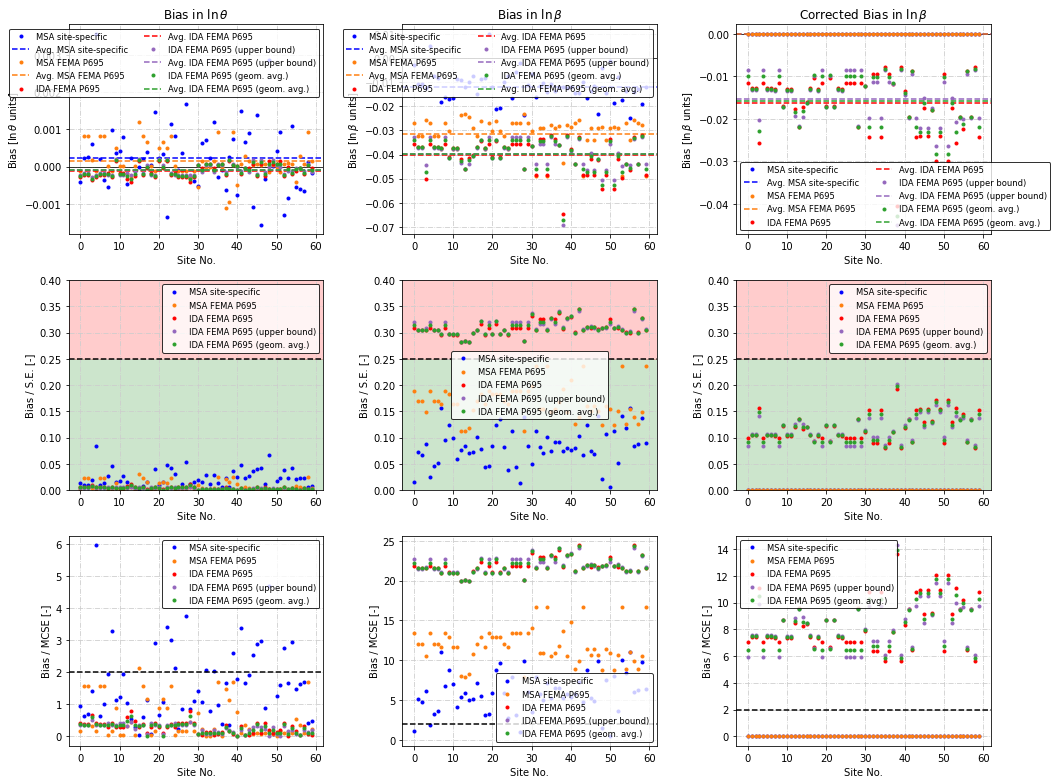

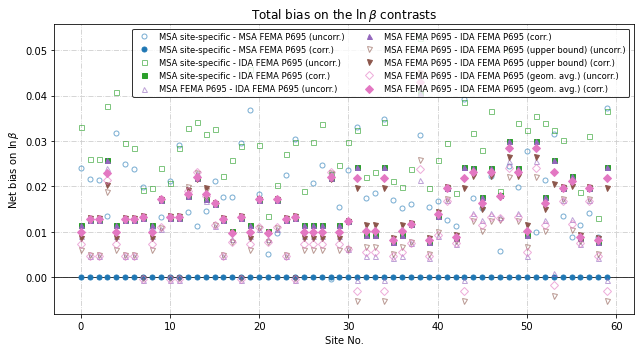

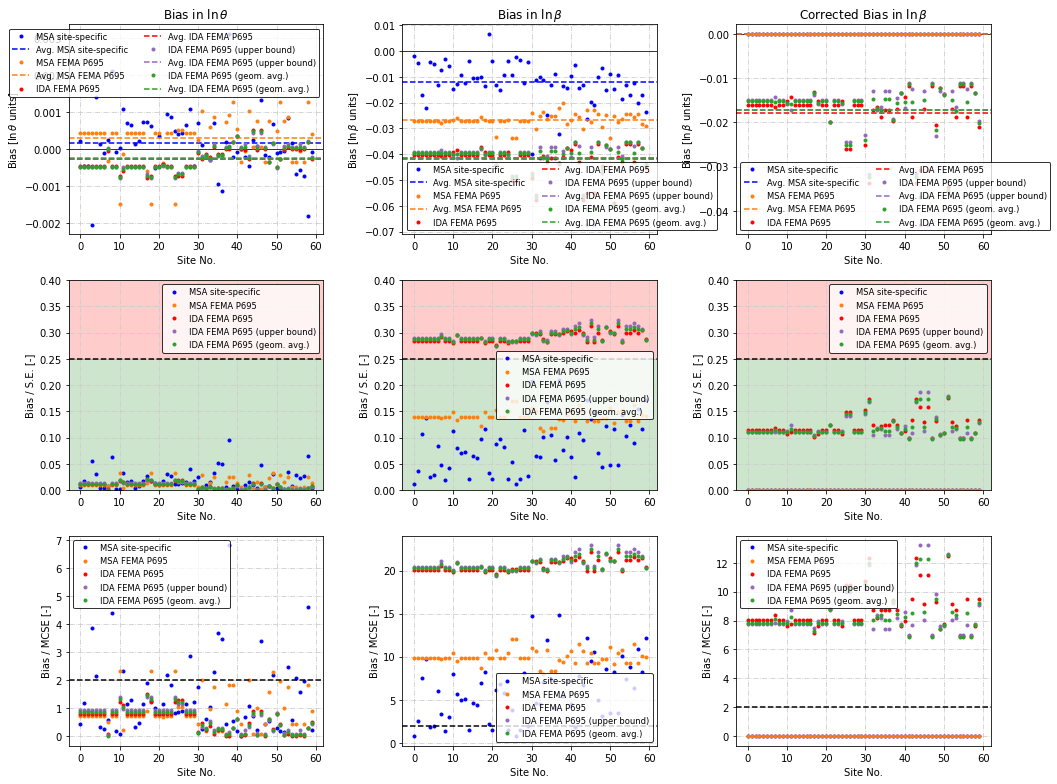

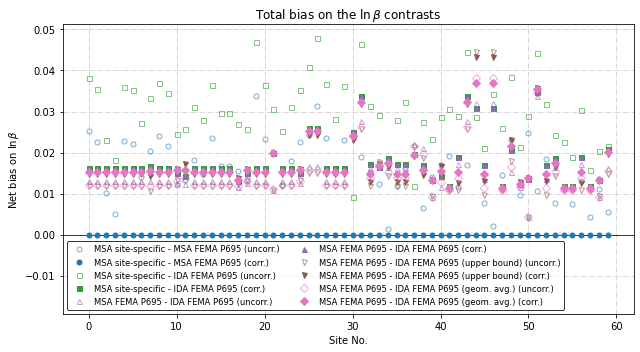

In [67]:
# With five arms the default all-pairs contrast set is larger than the figure can carry,
# so the comparisons that matter are named: the two MSA arms against each other, and each
# IDA bracket variant against the FEMAP695 MSA it is meant to reproduce.
BIAS_CONTRASTS = ([("site_msa", "msa_femap695"), ("site_msa", "ida_femap695"),
                   ("msa_femap695", "ida_femap695")]
                  + [("msa_femap695", BRACKET_ARM[v]) for v in BRACKET_VARIANTS])

for n in N_STOREYS:
    print(f"[{n}s]")
    fig1, axs1, fig2, axs2 = mra.plot_bias_assessment(bias_by_site[n],
                                                      refs_by_site[n],
                                                      contrasts=BIAS_CONTRASTS)


### 2.4 Save

Written through the same `bootstrap_csv_path` convention as the clouds, with the quantity
suffixed `_bias`, so the bias frames sit alongside the replicates they came from. The two
FEMAP695 arms are saved both ways; the site-specific arm has no groups.

In [68]:
# The arm and quantity keys are the same at every storey count, so the first one names
# what has to be written and the storey counts are gathered under it.
for _scope, _bias_by_n in [("by_site", bias_by_site), ("by_group", bias_by_group)]:
    for _arm, _quantities in _bias_by_n[N_STOREYS[0]].items():
        for _quantity in _quantities:
            _merged = mra.stack_unit_frames(
                {n: _bias_by_n[n][_arm][_quantity] for n in N_STOREYS})
            out = mra.bias_csv_path(BOOTSTRAP_PTH, _arm, _quantity, IM_TAG, _scope)
            _merged.to_csv(out)
            print(f"wrote {out.name}  {_merged.shape}")


wrote site_msa_bootstrap_theta_bias_AvgSA_03_by_site.csv  (120, 11)
wrote site_msa_bootstrap_beta_bias_AvgSA_03_by_site.csv  (120, 11)
wrote msa_femap695_bootstrap_theta_bias_AvgSA_03_by_site.csv  (120, 11)
wrote msa_femap695_bootstrap_beta_bias_AvgSA_03_by_site.csv  (120, 11)
wrote ida_femap695_bootstrap_theta_bias_AvgSA_03_by_site.csv  (120, 11)
wrote ida_femap695_bootstrap_beta_bias_AvgSA_03_by_site.csv  (120, 11)
wrote ida_femap695_ub_bootstrap_theta_bias_AvgSA_03_by_site.csv  (120, 11)
wrote ida_femap695_ub_bootstrap_beta_bias_AvgSA_03_by_site.csv  (120, 11)
wrote ida_femap695_avg_bootstrap_theta_bias_AvgSA_03_by_site.csv  (120, 11)
wrote ida_femap695_avg_bootstrap_beta_bias_AvgSA_03_by_site.csv  (120, 11)
wrote msa_femap695_bootstrap_theta_bias_AvgSA_03_by_group.csv  (51, 11)
wrote msa_femap695_bootstrap_beta_bias_AvgSA_03_by_group.csv  (51, 11)
wrote ida_femap695_bootstrap_theta_bias_AvgSA_03_by_group.csv  (51, 11)
wrote ida_femap695_bootstrap_beta_bias_AvgSA_03_by_group.csv  (5